---

# <font color= #6c9cda> *AurumQuant: FFNN–GARCH Risk Architecture* </font>
- <Strong> Subject: </Strong>  <font color="#4875af">Non Linear Models  </font>
- <Strong> 2nd Exam </Strong>  <font color="#4875af">FNN & GARCH </font>
- <Strong> Participants: </Strong>  <font color="#4875af">Sarah Beltran, Sofia Maldonado, Cesar Santos, Roi Garza Stone</font>


<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

---

## <font color= #6c9cda> *Introducción* </font>

En este trabajo, el objetivo es explotar a fondo lo que las redes Feed-forward (FNN) pueden hacer en el mundo financiero. Queremos ver qué tan capaces son de aprender los patrones complejos del mercado y, también, compararlas frente al modelo más viejo, confiable y por excelencia en la industria, conocido como el modelo GARCH

Nos inspiramos en el Oro, porque es el activo por excelencia cuando buscas entender el balance entre movimiento y estabilidad. Es el refugio histórico, el respaldo de las reservas de los bancos centrales y, aunque parezca "seguro", tiene sus mañas y variaciones que lo hacen perfecto para este experimento.

---

## <font color= #6c9cda> *EDA y Limpieza* </font>

In [25]:
import yfinance as yf
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
from keras.losses import Huber
from arch import arch_model

In [26]:
gold = yf.Ticker("GC=F")
df = gold.history(period="7mo", interval = "1d")

df.index.name = None
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2025-09-15 00:00:00-04:00,3640.000000,3686.399902,3635.100098,3682.199951,210,0.0,0.0
2025-09-16 00:00:00-04:00,3681.399902,3698.600098,3681.399902,3688.899902,373,0.0,0.0
2025-09-17 00:00:00-04:00,3669.000000,3685.199951,3661.600098,3681.800049,183,0.0,0.0
2025-09-18 00:00:00-04:00,3654.600098,3667.399902,3637.000000,3643.699951,80,0.0,0.0
2025-09-19 00:00:00-04:00,3659.000000,3685.899902,3658.199951,3671.500000,211,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-06 00:00:00-04:00,4656.100098,4689.600098,4605.000000,4656.799805,148,0.0,0.0
2026-04-07 00:00:00-04:00,4624.899902,4676.299805,4608.000000,4657.100098,327,0.0,0.0
2026-04-08 00:00:00-04:00,4760.000000,4851.000000,4738.799805,4749.500000,405,0.0,0.0
2026-04-09 00:00:00-04:00,4711.000000,4799.100098,4711.000000,4792.200195,1277,0.0,0.0


In [27]:
# Eliminación de columnas no informativas para el modelo
df.drop(columns=['Dividends', 'Stock Splits'], inplace=True, errors='ignore')

# Verificación de la limpieza
df.head()

,Open,High,Low,Close,Volume
2025-09-15 00:00:00-04:00,3640.000000,3686.399902,3635.100098,3682.199951,210
2025-09-16 00:00:00-04:00,3681.399902,3698.600098,3681.399902,3688.899902,373
2025-09-17 00:00:00-04:00,3669.000000,3685.199951,3661.600098,3681.800049,183
2025-09-18 00:00:00-04:00,3654.600098,3667.399902,3637.000000,3643.699951,80
2025-09-19 00:00:00-04:00,3659.000000,3685.899902,3658.199951,3671.500000,211


In [28]:
# Crear figura con Plotly
fig = go.Figure()

# Añadir traza del precio de cierre
fig.add_trace(go.Scatter(
    x=df.index, 
    y=df['Close'],
    mode='lines',
    name='Precio de Cierre (Gold)',
    line=dict(color='#6c9cda', width=2)
))

# Configuración del diseño
fig.update_layout(
    title='Evolución Histórica del Oro (GC=F) - Últimos 3 Meses',
    xaxis_title='Fecha',
    yaxis_title='Precio (USD)',
    template='plotly_white',
    hovermode='x unified',
    margin=dict(l=20, r=20, t=50, b=20)
)

# Mostrar gráfico
fig.show()

Decidimos cargar datos desde el 12 de septiembre del 2025 hasta el 10 de abril (el viernes, porque los fines de semana cierran los mercados). Viendo los datos, parece que el oro *en general* ha estado subiendo, excepto por una caída muy fuerte a finales de enero de este año y una cierta estagnación en lo poco que va del mes. Esto podría afectar nuestras predicciones.

---

## <font color= #6c9cda> *Pruebas de Estacionareidad* </font>

Aqui van las pruebas de estacionareidad

In [29]:
def check_stationarity(series, title="Serie Original"):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    is_stationary = result[1] < 0.05
    print(f"¿Es estacionaria? {'SÍ' if is_stationary else 'NO'}\n")
    return is_stationary

# 1. Revisamos la serie original
check_stationarity(df['Close'], "Tipo de Cambio Original")

# 2. Aplicamos Primera Diferencia (d=1)
df['diff_1'] = df['Close'].diff()

# 3. Revisamos la serie diferenciada
check_stationarity(df['diff_1'], "Primera Diferencia (d=1)")

# Creamos una figura con 2 columnas (Subplots)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Serie Original (No Estacionaria)", "Serie Diferenciada (Estacionaria d=1)")
)

# Gráfico 1: Serie Original
fig.add_trace(
    go.Scatter(x=df['Close'].index, y=df['Close'], name='Original'),
    row=1, col=1
)

# Gráfico 2: Serie Diferenciada
fig.add_trace(
    go.Scatter(x=df['diff_1'].index, y=df['diff_1'], name='Diferenciada'),
    row=1, col=2
)

# Ajustes de diseño
fig.update_layout(
    title_text="Comparativa: Efecto de la Diferenciación",
    showlegend=False, # Ocultamos leyenda
    height=500
)

fig.show()

ADF Test: Tipo de Cambio Original
Estadístico ADF: -1.7462
p-value: 0.4075
¿Es estacionaria? NO

ADF Test: Primera Diferencia (d=1)
Estadístico ADF: -12.5379
p-value: 0.0000
¿Es estacionaria? SÍ



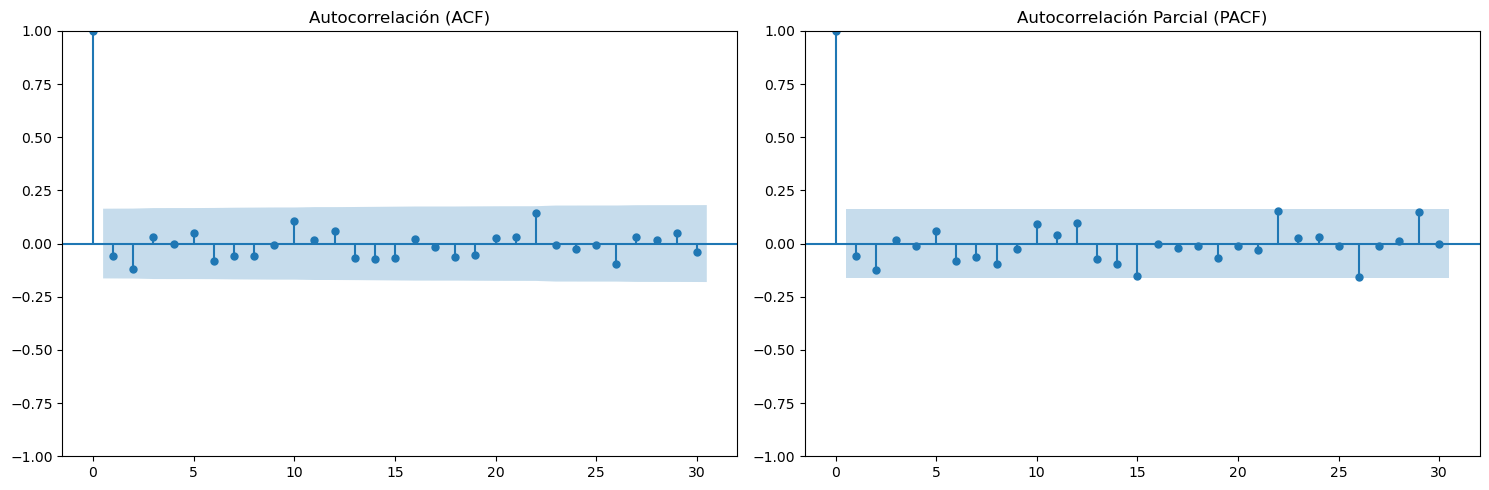

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. Gráfico de Autocorrelación (ACF) - Útil para identificar el término MA (q)
plot_acf(df["diff_1"].dropna(), lags=30, ax=axes[0], title='Autocorrelación (ACF)')

# 4. Gráfico de Autocorrelación Parcial (PACF) - Útil para identificar el término AR (p)
plot_pacf(df["diff_1"].dropna(), lags=30, ax=axes[1], title='Autocorrelación Parcial (PACF)', method='yw')

plt.tight_layout()
plt.show()

---

## <font color= #6c9cda> *FNN* </font>

Para nuestra FNN, decidimos usar una ventana deslizante de 25. 

In [31]:
serie_diff = df['diff_1'].dropna().values

# Definimos la función de ventana deslizante
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 25
X, y = crear_ventanas(serie_diff, window_size=window_size)

# Split de Entrenamiento y Prueba 
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Escalado de Datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_preds = StandardScaler()
y_train_scaled = scaler_preds.fit_transform(y_train.reshape(-1,1))

Nuestra red es muy sencilla, consistiendo únicamente de dos capas fully connected (o densas), con capas de Dropout para "apagar" algunas neuronas. Tiene apenas 5899 parámetors en total.

In [32]:
# Construcción del modelo
model = Sequential([
    # Primera capa oculta de 32 neuronas
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dropout(0.1),
    
    Dense(64, activation="relu"),
    Dropout(0.1), 
    
    # Capa de salida (predice el siguiente valor de diff_1)
    Dense(1) 
])

print(model.summary())



c:\Users\sarah\anaconda3\envs\escuela\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

None


Como se nos va a evaluar utilizando la directional accuracy, usamos esta como la métrica para utilizar a la hora de compilar y entrenar el modelo. Tensorflow no pareció tener algún método ya creado para esto, así que se tuvo que escribir a mano. Sin embargo, como se ve abajo esta es una fórmula muy sencilla de implementar. Como nota, esta función predice la Mean Directional Accuracy (MDA), más común cuando se trabaja con DA.

Buscando en internet encontramos la pérdida de Huber (Huber loss) inventada por Peter Jost Huber. Esta es una pérdida para problemas de regresión que es menos sensible a outliers, de los cuáles tenemos muchos. Afortunadamente, esta función de pérdida si está implementada en Keras, y pudimos ingresarla directamente.

In [33]:
def directional_accuracy(y_true, y_pred):
    return tf.reduce_mean(
        tf.cast(tf.equal(tf.sign(y_true), tf.sign(y_pred)), tf.float32)
    )

# Compilación
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss=Huber(delta=1),
    metrics=[directional_accuracy]
)

# Entrenamiento
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=50,      
    batch_size=32,    # Batch pequeño suele ayudar en series de tiempo cortas
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - directional_accuracy: 0.4451 - loss: 0.3823 - val_directional_accuracy: 0.4211 - val_loss: 0.6188
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - directional_accuracy: 0.5663 - loss: 0.3307 - val_directional_accuracy: 0.3158 - val_loss: 0.5477
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - directional_accuracy: 0.5663 - loss: 0.2903 - val_directional_accuracy: 0.3684 - val_loss: 0.5450
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - directional_accuracy: 0.5464 - loss: 0.2940 - val_directional_accuracy: 0.4211 - val_loss: 0.5509
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - directional_accuracy: 0.5047 - loss: 0.3017 - val_directional_accuracy: 0.3684 - val_loss: 0.5451
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - directional_accuracy: 0.5464 - loss: 0.2699 - val_directional_accuracy: 0.3158 - val_loss: 0.5342
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - directional_accuracy: 0.5455 - loss: 0.2639 - val_dire

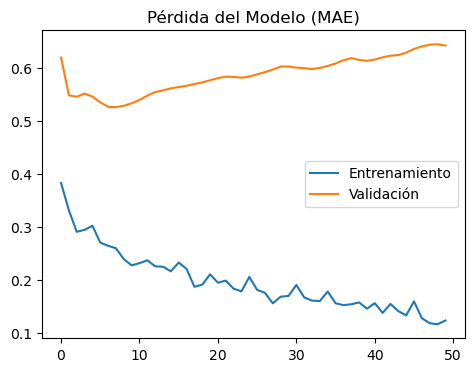

In [34]:
plt.figure(figsize=(12, 4))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (MAE)')
plt.legend()

plt.show()

In [35]:
fig_fnn = go.Figure()
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_preds.inverse_transform(y_pred_scaled)

# Línea de valores reales
fig_fnn.add_trace(go.Scatter(
    y=y_test, 
    mode='lines', 
    name='Real (diff_1)',
    line=dict(color='royalblue', width=2)
))

# Línea de predicción de la red neuronal
fig_fnn.add_trace(go.Scatter(
    y=y_pred.flatten(), 
    mode='lines', 
    name='Predicción FNN',
    line=dict(color='firebrick', width=2, dash='dot')
))

fig_fnn.update_layout(
    title='Validación FNN: Predicción de Retornos (Set de Prueba)',
    xaxis_title='Muestras (Tiempo)',
    yaxis_title='Valor de diff_1',
    hovermode='x unified',
    template='plotly_white'
)

fig_fnn.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


El modelo parece haber captado la tendencia general muy bien. El valor de MDA de entrenamiento está arriba de 0.8, un resultado muy bueno considerando la volatilidad que se puede observar en el oro. Viendo unas predicciones rápidas, parece entender los patrones del precio del oro muy bien. Ahora, solo falta hacer las predicciones para el 13-17 de abril.

In [36]:
last_window = X_test[-1]   
last_window_scaled = scaler.transform(last_window.reshape(1, -1))

future_preds = []

current_window = last_window.copy()

for _ in range(5): 
    # Haciendo todo el proceso de nuevo, escalando los datos en la ventana específica, haciendo las predicciones y volviendo a las escalas originales.
    current_window_scaled = scaler.transform(current_window.reshape(1, -1))
    
    pred_scaled = model.predict(current_window_scaled)
    
    pred = scaler_preds.inverse_transform(pred_scaled)[0,0]
    
    future_preds.append(pred)
    
    current_window = np.append(current_window[1:], pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [37]:
future_preds

[np.float32(14.99511),
 np.float32(51.054535),
 np.float32(32.1562),
 np.float32(38.424435),
 np.float32(28.347496)]

In [38]:
df_resultados_fnn = pd.DataFrame(future_preds, columns=['resultados'])
df_resultados_fnn

,resultados
0,14.995110
1,51.054535
2,32.156200
3,38.424435
4,28.347496


In [39]:
df_resultados_fnn.to_excel('preds_oro_fnn.xlsx')
# LINEA COMENTADA PARA NO GENERAR OTRO EXCEL CON EJECUCIONES FUTURAS

---

## <font color= #6c9cda> *GARCH* </font>

Antes de implementar el modelo GARCH final, se iteró varias veces, pero 2 son notables de mencionar:

1. Se utiizó una GARCH normal, pero sus estimaciones eran bastante malas, ya que en el test, los datos se salían varias veces del rango establecido por la GARCH. Esto podía ser comprobado ya que los parámetross $\alpha + \beta = 1$.

2. Luego se decidió implementar un "clipping" a la serie de tiempo, ya que los valores atípicos (junto con la corta muestra), podían generar un sesgo significativo en los datos. Aunque los resultados parecían buenos $\alpha + \beta \lt 1$, la banda de confianza era ridiculamente alta, practicamente cualquier estimación iba a caer dentro de ese rango.

Asi que se optó por entrenar la GARCH con un rolling window y con esto lograr que el modelo se entrenara en cada paso y que dinámicamente fuera re-calibrando el umbral de decisión, haciéndolo adaptable y robusto ante fluctuaciones.

In [40]:
# Train/Test Split
split_idx = int(len(df["diff_1"]) * 0.8)
train_data = df["diff_1"].iloc[:split_idx].dropna().values
test_data = df["diff_1"].iloc[split_idx:]

history = list(train_data)
predictions = []

for i in range(len(test_data)):
    # Entrenar modelo con distribución t-student
    model = arch_model(history, vol='Garch', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    
    # Predecir solo el SIGUIENTE paso (horizon=1)
    pred = res.forecast(horizon=1, reindex=False)
    vol_next = np.sqrt(pred.variance.values[-1, 0])
    predictions.append(vol_next)
    
    # Añadir el dato REAL observado a la historia para la siguiente iteración
    history.append(test_data.iloc[i])

# Convertir a serie para graficar
rolling_vol = pd.Series(predictions, index=test_data.index)

In [41]:
# Preparar los datos
indices_test = test_data.index
vol_test_series = pd.Series(rolling_vol, index=test_data.index)

fig_garch = go.Figure()

# Retornos reales en el set de prueba
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=test_data,
    mode='lines',
    name='Retornos Reales',
    line=dict(color='grey', width=1),
    opacity=0.5
))

# Banda Superior de Volatilidad
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=vol_test_series,
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

# Banda Inferior de Volatilidad con Relleno (Shading)
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=-vol_test_series,
    mode='lines',
    line=dict(width=0),
    fill='tonexty', # Rellena hacia la traza anterior
    fillcolor='rgba(255, 0, 0, 0.2)',
    name='Volatilidad Pronosticada (Intervalo)'
))

# Línea de contorno para que se vea definida
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=vol_test_series,
    mode='lines',
    line=dict(color='red', width=2),
    name='Límite de Volatilidad'
))

fig_garch.update_layout(
    title='Validación GARCH: Pronóstico de Volatilidad (Out-of-Sample)',
    xaxis_title='Fecha',
    yaxis_title='Magnitud',
    template='plotly_dark', # El modo oscuro resalta muy bien las bandas rojas
    hovermode='x unified'
)

fig_garch.show()

Este modelo GARCH parece aprender adecuadamente la varianza de la serie de tiempo.

In [42]:
# Obtenemos los grados de libertad (nu) estimados por tu modelo
# 'res' es el objeto que obtuviste de model.fit()
nu_estimado = res.params['nu']

# Calculamos el cuantil crítico para el 95% de confianza con esa 'nu'
# Usamos el cuantil 0.05 para el límite inferior (Value at Risk)
t_critico = stats.t.ppf(0.05, df=nu_estimado)

# Calculamos el VaR (es negativo porque es pérdida)
var_95_t = rolling_vol * t_critico

# Conteo de excepciones (Rompimientos del límite inferior)
excepciones = test_data[test_data < var_95_t].count()
porcentaje_fallo = (excepciones / len(test_data)) * 100

print(f"Grados de libertad (nu): {nu_estimado:.2f}")
print(f"Porcentaje de fallo real: {porcentaje_fallo:.2f}%")

Grados de libertad (nu): 2.95
Porcentaje de fallo real: 3.45%


El razonamiento detrás de este modelo consiste en transformar la volatilidad condicional estimada por el GARCH en un Value at Risk (VaR) al 95% de confianza, utilizando una distribución t-Student para capturar correctamente las colas pesadas y los eventos extremos del oro. Los resultados obtenidos con el Rolling Window se validan mediante un backtesting donde las excepciones (dias en que el retorno real rompe el límite inferior) no superan el 5% de la muestra, demostrando que el modelo no subestima el riesgo ante choques de mercado.

In [43]:
# utilizamos el modelo entrenado
full_history = df["diff_1"].dropna().values

model_final = arch_model(full_history, vol='Garch', p=1, q=1, dist='t')
res_final = model_final.fit(disp='off')

future_preds = []

# GARCH permite forecast multi-paso directamente con horizon=5
forecast = res_final.forecast(horizon=5, reindex=False)

# Extraemos la varianza y la convertimos a volatilidad
for h in range(5):
    vol_futura = np.sqrt(forecast.variance.values[-1, h])
    future_preds.append(vol_futura)

In [44]:
df_resultados_garch = pd.DataFrame(future_preds, columns=['resultados'])
df_resultados_garch.index = range(1, 6)  # Paso 1 al 5
df_resultados_garch.index.name = 'horizonte'
df_resultados_garch

,resultados
horizonte,
1,107.278712
2,109.096013
3,110.883534
4,112.642693
5,114.374797


In [45]:
df_resultados_garch.to_excel('preds_oro_garch.xlsx')

---

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="imgs/ivanmamado.png" width="300">
</div>

---